Implement Deep Q-Learning Network to solve CartPole problem

In [ ]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

# Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.fc(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = map(np.array, zip(*batch))
        return (s, a, r, s_next, done)
    
    def __len__(self):
        return len(self.buffer)

# Hyperparameters
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
lr = 1e-3
gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
target_update = 10
num_episodes = 500

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayBuffer(10000)

# Training Loop
for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    for t in range(500):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(state_tensor).argmax().item()

        next_state, reward, done, trunc, _ = env.step(action)
        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        if len(memory) > batch_size:
            s, a, r, s_next, done_batch = memory.sample(batch_size)
            s = torch.FloatTensor(s).to(device)
            a = torch.LongTensor(a).unsqueeze(1).to(device)
            r = torch.FloatTensor(r).unsqueeze(1).to(device)
            s_next = torch.FloatTensor(s_next).to(device)
            done_batch = torch.FloatTensor(done_batch).unsqueeze(1).to(device)

            q_values = policy_net(s).gather(1, a)
            next_q_values = target_net(s_next).max(1)[0].unsqueeze(1)
            target = r + gamma * next_q_values * (1 - done_batch)

            loss = nn.MSELoss()(q_values, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done or trunc:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

env.close()

Episode 1, Reward: 13.0, Epsilon: 0.995
Episode 2, Reward: 18.0, Epsilon: 0.990
Episode 3, Reward: 14.0, Epsilon: 0.985
Episode 4, Reward: 14.0, Epsilon: 0.980
Episode 5, Reward: 14.0, Epsilon: 0.975
Episode 6, Reward: 14.0, Epsilon: 0.970
Episode 7, Reward: 64.0, Epsilon: 0.966
Episode 8, Reward: 33.0, Epsilon: 0.961
Episode 9, Reward: 34.0, Epsilon: 0.956
Episode 10, Reward: 16.0, Epsilon: 0.951
Episode 11, Reward: 11.0, Epsilon: 0.946
Episode 12, Reward: 48.0, Epsilon: 0.942
Episode 13, Reward: 17.0, Epsilon: 0.937
Episode 14, Reward: 17.0, Epsilon: 0.932
Episode 15, Reward: 15.0, Epsilon: 0.928
Episode 16, Reward: 14.0, Epsilon: 0.923
Episode 17, Reward: 15.0, Epsilon: 0.918
Episode 18, Reward: 32.0, Epsilon: 0.914
Episode 19, Reward: 17.0, Epsilon: 0.909
Episode 20, Reward: 12.0, Epsilon: 0.905
Episode 21, Reward: 14.0, Epsilon: 0.900
Episode 22, Reward: 23.0, Epsilon: 0.896
Episode 23, Reward: 49.0, Epsilon: 0.891
Episode 24, Reward: 38.0, Epsilon: 0.887
Episode 25, Reward: 39.0,

Episode 1/400, Reward: 17.0, Loss: 0.0000, Epsilon: 0.995
Episode 2/400, Reward: 15.0, Loss: 0.0000, Epsilon: 0.990
Episode 3/400, Reward: 53.0, Loss: 0.2364, Epsilon: 0.985
Episode 4/400, Reward: 14.0, Loss: 0.0398, Epsilon: 0.980
Episode 5/400, Reward: 28.0, Loss: 0.0138, Epsilon: 0.975
Episode 6/400, Reward: 12.0, Loss: 0.0026, Epsilon: 0.970
Episode 7/400, Reward: 12.0, Loss: 0.0009, Epsilon: 0.966
Episode 8/400, Reward: 22.0, Loss: 0.0004, Epsilon: 0.961
Episode 9/400, Reward: 59.0, Loss: 0.0002, Epsilon: 0.956
Episode 10/400, Reward: 26.0, Loss: 0.0001, Epsilon: 0.951
Episode 11/400, Reward: 15.0, Loss: 0.0002, Epsilon: 0.946
Episode 12/400, Reward: 22.0, Loss: 0.1314, Epsilon: 0.942
Episode 13/400, Reward: 31.0, Loss: 0.0236, Epsilon: 0.937
Episode 14/400, Reward: 14.0, Loss: 0.0163, Epsilon: 0.932
Episode 15/400, Reward: 48.0, Loss: 0.0144, Epsilon: 0.928
Episode 16/400, Reward: 19.0, Loss: 0.0153, Epsilon: 0.923
Episode 17/400, Reward: 26.0, Loss: 0.0134, Epsilon: 0.918
Episod

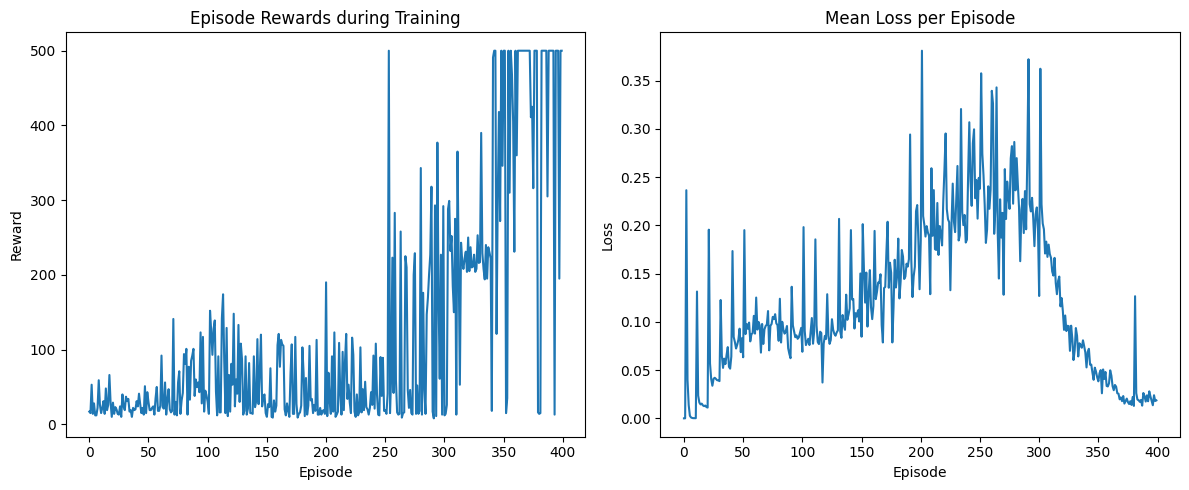

Test Episode 1: Reward = 500.0
Test Episode 2: Reward = 500.0
Test Episode 3: Reward = 500.0
Test Episode 4: Reward = 500.0
Test Episode 5: Reward = 500.0
Test Episode 6: Reward = 500.0
Test Episode 7: Reward = 500.0
Test Episode 8: Reward = 500.0
Test Episode 9: Reward = 500.0
Test Episode 10: Reward = 500.0

Average Test Reward: 500.00


In [6]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Q-Network 
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.fc(x)

# Replay Buffer 
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = map(np.array, zip(*batch))
        return (s, a, r, s_next, done)
    
    def __len__(self):
        return len(self.buffer)

# Hyperparameters 
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
lr = 1e-3
gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
target_update = 10
num_episodes = 400

# Initialize 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayBuffer(10000)

# Track metrics 
episode_rewards = []
episode_losses = []

# Training Loop 
for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    losses = []

    for t in range(500):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(state_tensor).argmax().item()

        next_state, reward, done, trunc, _ = env.step(action)
        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        # Train step
        if len(memory) > batch_size:
            s, a, r, s_next, done_batch = memory.sample(batch_size)
            s = torch.FloatTensor(s).to(device)
            a = torch.LongTensor(a).unsqueeze(1).to(device)
            r = torch.FloatTensor(r).unsqueeze(1).to(device)
            s_next = torch.FloatTensor(s_next).to(device)
            done_batch = torch.FloatTensor(done_batch).unsqueeze(1).to(device)

            q_values = policy_net(s).gather(1, a)
            next_q_values = target_net(s_next).max(1)[0].unsqueeze(1)
            target = r + gamma * next_q_values * (1 - done_batch)

            loss = nn.SmoothL1Loss()(q_values, target)  # Huber loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        if done or trunc:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    episode_rewards.append(total_reward)
    mean_loss = np.mean(losses) if losses else 0
    episode_losses.append(mean_loss)

    print(f"Episode {episode+1}/{num_episodes}, Reward: {total_reward}, Loss: {mean_loss:.4f}, Epsilon: {epsilon:.3f}")

env.close()

# Plot training metrics 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(episode_rewards)
plt.title("Episode Rewards during Training")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1,2,2)
plt.plot(episode_losses)
plt.title("Mean Loss per Episode")
plt.xlabel("Episode")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

# Testing after training 
test_episodes = 10
test_rewards = []

for ep in range(test_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        with torch.no_grad():
            action = policy_net(torch.FloatTensor(state).unsqueeze(0).to(device)).argmax().item()
        next_state, reward, done, trunc, _ = env.step(action)
        total_reward += reward
        state = next_state
        if done or trunc:
            break

    test_rewards.append(total_reward)
    print(f"Test Episode {ep+1}: Reward = {total_reward}")

print(f"\nAverage Test Reward: {np.mean(test_rewards):.2f}")
env.close()
